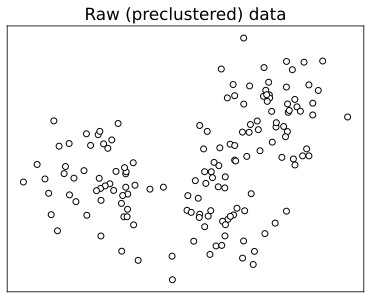

150


In [40]:
import plotly.express as px

import pandas as pd

import numpy as np

import matplotlib.pyplot as plt



# NOTE: these lines define global figure properties used for publication.

import matplotlib_inline.backend_inline

matplotlib_inline.backend_inline.set_matplotlib_formats('svg') # print figures in svg format

plt.rcParams.update({'font.size':14}) # set global font size



## Create data

nPerClust = 50



# blur around centroid (std units)

blur = 1



# XY centroid locations

A = [  1, 1 ]

B = [ -3, 1 ]

C = [  3, 3 ]



# generate data

a = [ A[0]+np.random.randn(nPerClust)*blur , A[1]+np.random.randn(nPerClust)*blur ]

b = [ B[0]+np.random.randn(nPerClust)*blur , B[1]+np.random.randn(nPerClust)*blur ]

c = [ C[0]+np.random.randn(nPerClust)*blur , C[1]+np.random.randn(nPerClust)*blur ]



# concatanate into a matrix

data = np.transpose( np.concatenate((a,b,c),axis=1) )





# plot data

plt.plot(data[:,0],data[:,1],'ko',markerfacecolor='w')

plt.title('Raw (preclustered) data')

plt.xticks([])

plt.yticks([])

df = pd.DataFrame(data, columns=['x', 'y'])

fig = px.scatter(df, x='x', y='y')

fig.show()

plt.show()

k = 3

ridx = np.random.choice(range(len(data)),k,replace=False)

centroids = data[ridx,:] # data matrix is samples by features

dists = np.zeros((data.shape[0],k))

for ci in range(k):

    dists[:,ci] = np.sum((data-centroids[ci,:])**2,axis =1)

    

groupidx = np.argmin(dists,axis=1)

for ki in range(k):

    centroids[ki,:] = [ np.mean(data[groupidx==ki,0]),

                       np.mean(data[groupidx==ki,1]) ]

print(len(data))

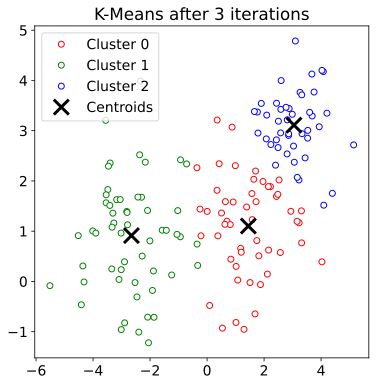

In [23]:

import matplotlib.pyplot as plt

# We will iterate 3 times as requested
num_iterations = 3

for iteration in range(num_iterations):
    
    # 1. Calculate Distances (from all points to all centroids)
    for ci in range(k):
        dists[:, ci] = np.sum((data - centroids[ci, :])**2, axis=1)
        
    # 2. Assign Groups (find the index of the minimum distance for each point)
    groupidx = np.argmin(dists, axis=1)
    
    # 3. Update Centroids (move centroid to the mean of its new group)
    for ki in range(k):
        # axis=0 calculates the mean of X and Y columns at the same time
        centroids[ki, :] = np.mean(data[groupidx == ki], axis=0)

# ---------------------------------------------------------
# Plot the final clustered data
# ---------------------------------------------------------
# Colors for the 3 groups
colors = ['r', 'g', 'b']

plt.figure(figsize=(6, 6))

# Plot each data point with the color of its assigned group
for ki in range(k):
    # Select only the points assigned to group ki
    plt.plot(data[groupidx == ki, 0], data[groupidx == ki, 1], colors[ki] + 'o', markerfacecolor='w', label=f'Cluster {ki}')
    
# Plot the final centroids on top as large black X's
plt.plot(centroids[:, 0], centroids[:, 1], 'kx', markersize=15, markeredgewidth=3, label='Centroids')

plt.title(f'K-Means after {num_iterations} iterations')
plt.legend()
plt.show()


In [41]:
print(type(a))        # <class 'list'>
print(len(a))         # 2
print(type(a[0]))     # <class 'numpy.ndarray'>
print(type(a[1]))     # <class 'numpy.ndarray'>
print(a[0].shape)     # (50,)  # (50,)
print(a[0])

<class 'list'>
2
<class 'numpy.ndarray'>
<class 'numpy.ndarray'>
(50,)
[ 1.27611739  2.19860627  1.46092566  0.56892415  1.386456    0.53284565
  1.93229531  0.18875063  0.78403266  1.62327777  0.96800977  1.16876958
  0.61135032  0.75527448  1.58143938  0.39814614  1.61926011  1.65553951
  2.83327495  1.29226818  3.03729947 -0.55905816  1.06619371  2.26953093
  0.89855214 -0.04689781  1.46975272  0.66083628  0.38157929  0.24246347
  1.10097451  1.97114599  1.19720412  1.04686581 -0.87373785  1.29792453
  3.43250423 -0.01811397  2.311813    0.84384396  0.39612012  0.6934088
  2.67835848  1.7015612   2.91483497  0.10014506  1.27963195  0.57174273
  1.8959983   0.34493714]


In [44]:
ff = np.array([1,2,3,4,5,6])
diag = np.diag(ff)
print(diag)
jokk = np.diag(diag)
print(jokk)


[[1 0 0 0 0 0]
 [0 2 0 0 0 0]
 [0 0 3 0 0 0]
 [0 0 0 4 0 0]
 [0 0 0 0 5 0]
 [0 0 0 0 0 6]]
[1 2 3 4 5 6]
